# Project on Predicting Cotton Condition in Pakistan

In this project cotton condition is predicted. Sattelite images are accessed via Google Earth Engine API (I created a project called cottoncondition).
For now, this notebook loads the field boundaries from a shapefile, and loads the corresponding satellite images from Kharif - 2022.

As a test monthly and weekly NDVI median values are plotted for a field.
The mean NDVI + STD is plotted for the 90 cotton fields. 

Experimental approaches for phenological allignments are attemped, but will be changed/adjusted soon.

### Import packages

In [1]:
import ee
import geemap
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### Connect to GEE 

In [2]:
# Authenticate and connect to GEE API
ee.Authenticate()  # opens browser once, caches token locally
ee.Initialize(project="cottoncondition")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


### Define Parameters 

In [16]:
start_date = "2022-04-01"
end_date   = "2022-10-31"

months = ee.List.sequence(4, 10)


FIELDS_SHP_PATH = r"C:\Users\donle\Desktop\Cotton Condition\QGIS Project\Vector Layers\cotton_in_pakistan.shp"
LABELS_SHP_PATH = r"C:\Users\donle\Desktop\SmallPAK\Data\Labels\Important_Labels.shp"

SCALE = 10                 # meters
CLOUD_PCT_THRESHOLD = 40   # max CLOUDY_PIXEL_PERCENTAGE for S2 scenes
S1_ORBIT_PASS = "ASCENDING"  # pick one orbit to avoid mixing incidence angles

MAX_SHIFT_MONTHS = 2  # phenology alignment search window, limited by the 7-month season

field_id = 1

### Load Field Boundaries

In [17]:
fields = gpd.read_file(LABELS_SHP_PATH)
fields = fields.to_crs(epsg=4326)  # GEE expects WGS84
fields = fields.reset_index(drop=True)
fields["field_id"] = fields.index

# bounding box covering all fields, as an ee.Geometry
minx, miny, maxx, maxy = fields.total_bounds
aoi = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

# fields as an ee.FeatureCollection, for later per-field stats
fields_fc = geemap.geopandas_to_ee(fields)

# geometry for the single demo field used throughout the notebook
field_geom = geemap.geopandas_to_ee(fields.iloc[[field_id]]).geometry()

### Load Field Labels

In [18]:
photos = gpd.read_file(LABELS_SHP_PATH)
photos = photos.to_crs(fields.crs)  # match CRS before any spatial join

# spatial join: attach each photo point's attributes to the field polygon
# that contains it (points are assumed to fall precisely inside their field)
fields_with_labels = gpd.sjoin(
    fields, photos, how="left", predicate="contains"
)

### Build Sentinel Collections

In [21]:
def mask_s2_clouds(image):
    scl = image.select("SCL")
    # keep vegetation, bare soil, water; drop cloud/shadow/cirrus/snow classes
    mask = scl.remap([4, 5, 6, 11], [1, 1, 1, 1], 0)
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
    .map(mask_s2_clouds)
)

In [22]:
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))  # pick one orbit to avoid mixing angles
)

In [23]:
def monthly_composite(collection, start_date, end_date):
    start = ee.Date(start_date)
    end = ee.Date(end_date)
    n_months = end.difference(start, "month").floor()
    month_starts = ee.List.sequence(0, n_months.subtract(1))

    def _make(i):
        i = ee.Number(i)
        m_start = start.advance(i, "month")
        m_end = m_start.advance(1, "month")
        img = collection.filterDate(m_start, m_end).median()
        return img.set({
            "system:time_start": m_start.millis(),
            "month": m_start.get("month"),
        })

    return ee.ImageCollection(month_starts.map(_make))

### Print Labels

In [33]:
score_cols = ["leaf_con", "canopy_den", "a_leaf_con", "a_cnpy_den"]

labels = fields[score_cols].copy()
labels[score_cols] = labels[score_cols].apply(pd.to_numeric, errors="coerce")

labels["avg"] = labels[score_cols].sum(axis=1, min_count=1)/4


# labels["avg"].value_counts().sort_index()
labels

,leaf_con,canopy_den,a_leaf_con,a_cnpy_den,avg
0,0.0,0.0,0.0,0.0,0.00
1,0.0,2.0,0.0,1.0,0.75
2,2.0,2.0,2.0,2.0,2.00
3,1.0,0.0,2.0,2.0,1.25
4,0.0,2.0,0.0,2.0,1.00
...,...,...,...,...,...
85,2.0,2.0,2.0,2.0,2.00
86,0.0,0.0,1.0,0.0,0.25
87,0.0,2.0,0.0,1.0,0.75
88,NaN,NaN,NaN,NaN,NaN


In [38]:
print(labels["canopy_den"].value_counts())

print(labels["a_cnpy_den"].value_counts())

canopy_den
0.0    30
1.0    29
2.0    27
Name: count, dtype: int64
a_cnpy_den
0.0    38
1.0    25
2.0    23
Name: count, dtype: int64


In [39]:
print(labels["leaf_con"].value_counts())

print(labels["a_leaf_con"].value_counts())

leaf_con
0.0    49
1.0    24
2.0    13
Name: count, dtype: int64
a_leaf_con
0.0    43
1.0    28
2.0    15
Name: count, dtype: int64


## Plot NDVI

### Monthly

In [24]:
def add_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)

def extract_ndvi(image):
    stat = image.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=field_geom,
        scale=10,
        maxPixels=1e9,
    )
    return ee.Feature(None, {
        "month": image.get("month"),
        "ndvi": stat.get("NDVI"),
    })

s2_ndvi = s2.map(add_ndvi)
s2_ndvi_monthly = monthly_composite(s2_ndvi.select("NDVI"), start_date, end_date)

In [25]:
field_geom = geemap.geopandas_to_ee(fields.iloc[[field_id]]).geometry()

ndvi_fc = ee.FeatureCollection(s2_ndvi_monthly.map(extract_ndvi))
ndvi_list = ndvi_fc.getInfo()["features"]


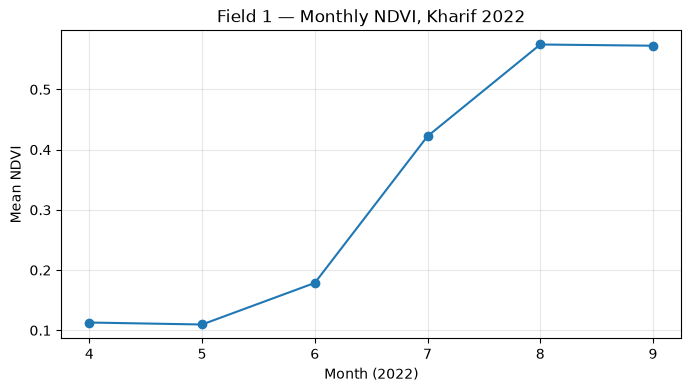

In [26]:
records = [f["properties"] for f in ndvi_list]
df = pd.DataFrame(records).sort_values("month")

plt.figure(figsize=(8, 4))
plt.plot(df["month"], df["ndvi"], marker="o")
plt.xlabel("Month (2022)")
plt.ylabel("Mean NDVI")
plt.title(f"Field {field_id} — Monthly NDVI, Kharif 2022")
plt.grid(True, alpha=0.3)
plt.show()

### Weekly NDVI

In [61]:
def weekly_composite(collection, start_date, end_date):
    start = ee.Date(start_date)
    end = ee.Date(end_date)
    n_weeks = end.difference(start, "week").floor()
    week_starts = ee.List.sequence(0, n_weeks.subtract(1))

    def _make(w):
        w = ee.Number(w)
        wk_start = start.advance(w, "week")
        wk_end = wk_start.advance(1, "week")
        weekly = collection.filterDate(wk_start, wk_end)
        img = weekly.median()
        return img.set({
            "week": w,
            "system:time_start": wk_start.millis(),
            "n_images": weekly.size(),
        })

    return ee.ImageCollection(week_starts.map(_make))


def extract_weekly_stats(image_collection, bands, geom, scale=SCALE):
    """One reduceRegion call per week, covering all bands at once."""
    images = image_collection.toList(image_collection.size())
    n = image_collection.size().getInfo()

    records = []
    for i in range(n):
        image = ee.Image(images.get(i))
        stat = image.reduceRegion(
            reducer=ee.Reducer.median(), geometry=geom, scale=scale, maxPixels=1e9,
        )
        info = ee.Dictionary({
            "week": image.get("week"), "n_images": image.get("n_images"), "stat": stat,
        }).getInfo()

        record = {"week": info["week"], "n_images": info["n_images"]}
        for band in bands:
            record[band] = info["stat"].get(band, None)
        records.append(record)

    return records


def stats_to_dataframe(records, bands):
    df = pd.DataFrame(records).sort_values("week").reset_index(drop=True)
    for band in bands:
        df[band] = pd.to_numeric(df[band], errors="coerce")
    return df

In [62]:
S2_CONFIG = {"label": "S2", "collection": s2_ndvi, "bands": ["NDVI"]}

s2_weekly = weekly_composite(S2_CONFIG["collection"].select(S2_CONFIG["bands"]), start_date, end_date)
ndvi_records = extract_weekly_stats(s2_weekly, S2_CONFIG["bands"], field_geom, scale=SCALE)
ndvi_df_w = stats_to_dataframe(ndvi_records, S2_CONFIG["bands"])


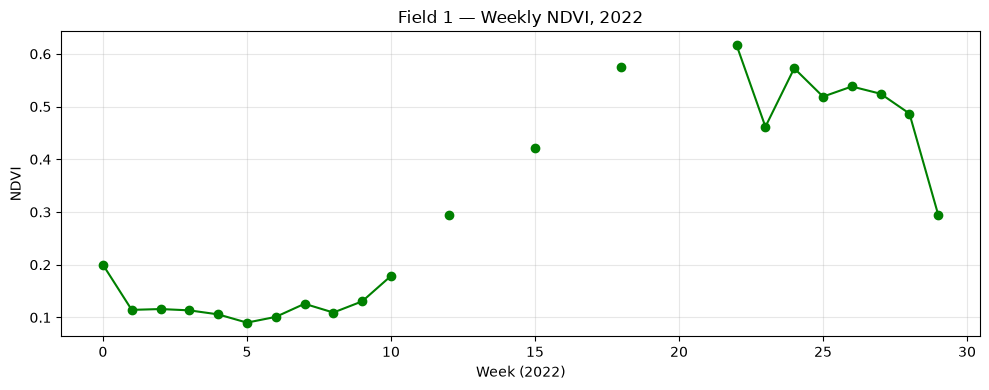

In [63]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ndvi_df_w["week"], ndvi_df_w["NDVI"], marker="o", color="green", linewidth=1.5)
ax.set_ylabel("NDVI")
ax.set_xlabel(f"Week ({2022})")
ax.set_title(f"Field {field_id} — Weekly NDVI, {2022}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
S1_CONFIG = {"label": "S1", "collection": s1, "bands": ["VV", "VH"]}

s1_weekly = weekly_composite(S1_CONFIG["collection"].select(S1_CONFIG["bands"]), start_date, end_date)
s1_records = extract_weekly_stats(s1_weekly, S1_CONFIG["bands"], field_geom, scale=SCALE)
s1_df_w = stats_to_dataframe(s1_records, S1_CONFIG["bands"])

In [65]:
s1_weekly = weekly_composite(
    S1_CONFIG["collection"].select(S1_CONFIG["bands"]),
    start_date, end_date,
)

s1_records = extract_weekly_stats(
    s1_weekly, S1_CONFIG["bands"], field_geom, scale=SCALE
)

s1_df_w = stats_to_dataframe(s1_records, S1_CONFIG["bands"])

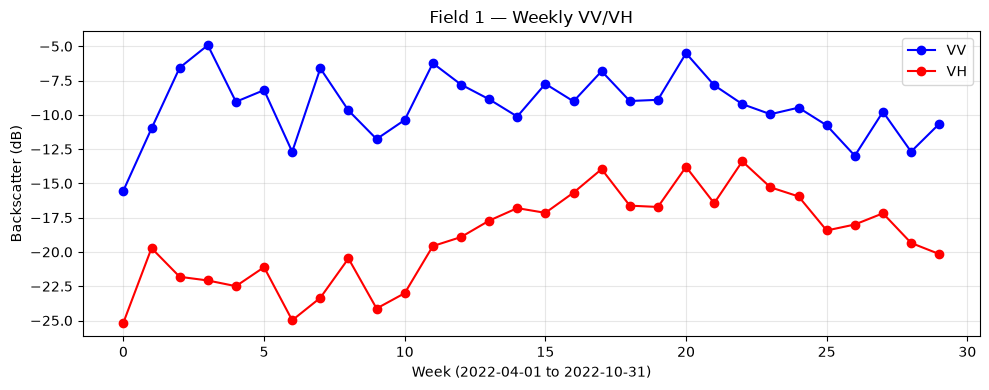

In [68]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(s1_df_w["week"], s1_df_w["VV"], marker="o", color="blue", label="VV", linewidth=1.5)
ax.plot(s1_df_w["week"], s1_df_w["VH"], marker="o", color="red", label="VH", linewidth=1.5)
ax.set_ylabel("Backscatter (dB)")
ax.set_xlabel(f"Week ({start_date} to {end_date})")
ax.set_title(f"Field {field_id} — Weekly VV/VH")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calculate Mean and Deviation in NDVI for all fields

In [69]:
def extract_ndvi_all_fields(image_collection, feature_collection, scale=10):
    n = image_collection.size().getInfo()
    image_list = image_collection.toList(n)

    rows = []
    for i in range(n):
        image = ee.Image(image_list.get(i))
        month = image.get("month").getInfo()

        stats_fc = image.reduceRegions(
            collection=feature_collection,
            reducer=ee.Reducer.median(),
            scale=scale,
        )

        for feat in stats_fc.getInfo()["features"]:
            props = feat["properties"]
            rows.append({
                "field_id": props["field_id"],
                "month": month,
                "ndvi": props.get("median"),
            })

    return pd.DataFrame(rows)


In [70]:

ndvi_df = extract_ndvi_all_fields(s2_ndvi_monthly, fields_fc)
ndvi_df["ndvi"] = pd.to_numeric(ndvi_df["ndvi"], errors="coerce")

monthly_summary = (
    ndvi_df.groupby("month")["ndvi"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("month")
)

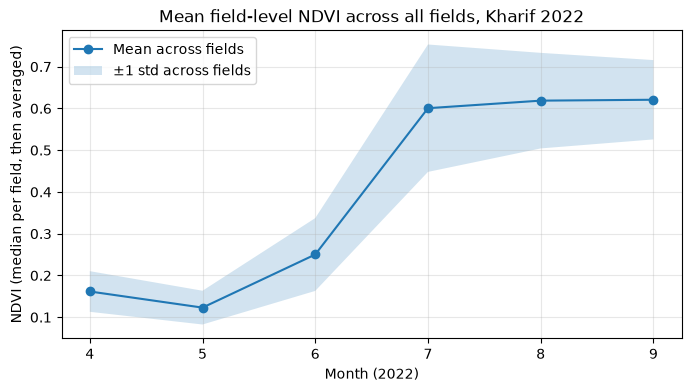

In [71]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_summary["month"], monthly_summary["mean"], marker="o", label="Mean across fields")
plt.fill_between(
    monthly_summary["month"],
    monthly_summary["mean"] - monthly_summary["std"],
    monthly_summary["mean"] + monthly_summary["std"],
    alpha=0.2,
    label="±1 std across fields",
)
plt.xlabel("Month (2022)")
plt.ylabel("NDVI (median per field, then averaged)")
plt.title("Mean field-level NDVI across all fields, Kharif 2022")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Experimental: Unsupervised Methods

### Shift On timeaxis to reduce NDVI difference

In [73]:
MAX_SHIFT_WEEKS = 4  # weekly alignment search window

def extract_ndvi_all_fields_weekly(image_collection, feature_collection, scale=SCALE):
    # drop weeks with zero source images — median() on those has no bands,
    # and reduceRegions throws on a bandless image
    image_collection = image_collection.filter(ee.Filter.gt("n_images", 0))

    n = image_collection.size().getInfo()
    image_list = image_collection.toList(n)

    rows = []
    for i in range(n):
        image = ee.Image(image_list.get(i))
        week = image.get("week").getInfo()

        stats_fc = image.reduceRegions(
            collection=feature_collection,
            reducer=ee.Reducer.median(),
            scale=scale,
        )
        for feat in stats_fc.getInfo()["features"]:
            props = feat["properties"]
            rows.append({
                "field_id": props["field_id"],
                "week": week,
                "ndvi": props.get("median"),
            })

    return pd.DataFrame(rows)

ndvi_weekly_all_df = extract_ndvi_all_fields_weekly(s2_weekly, fields_fc)
ndvi_weekly_all_df["ndvi"] = pd.to_numeric(ndvi_weekly_all_df["ndvi"], errors="coerce")

In [74]:
ndvi_weekly_wide = ndvi_weekly_all_df.pivot(index="field_id", columns="week", values="ndvi").sort_index(axis=1)

# keep only weeks where every field has a datapoint
complete_weeks_df = ndvi_weekly_wide.dropna(axis=1, how="any")

print(f"Weeks before filtering: {ndvi_weekly_wide.shape[1]}")
print(f"Weeks after filtering (complete across all fields): {complete_weeks_df.shape[1]}")

Weeks before filtering: 28
Weeks after filtering (complete across all fields): 18


In [75]:
baseline_std_per_week = complete_weeks_df.std(axis=0)
baseline_mean_std = baseline_std_per_week.mean()

print(f"Baseline mean std across fields (per week): {baseline_mean_std:.4f}")

Baseline mean std across fields (per week): 0.0818


In [76]:
reference = complete_weeks_df.mean(axis=0)  # across-field mean curve, per week
week_cols = complete_weeks_df.columns.to_numpy()

def best_shift_for_field_weekly(field_series, reference, week_cols, max_shift):
    best_shift, best_sse = 0, np.inf
    for shift in range(-max_shift, max_shift + 1):
        shifted_weeks = week_cols + shift
        valid = np.isin(shifted_weeks, week_cols)
        if valid.sum() < 3:  # require reasonable overlap to trust the fit
            continue
        field_vals = field_series.values[valid]
        ref_vals = reference.loc[shifted_weeks[valid]].values
        mask = ~np.isnan(field_vals) & ~np.isnan(ref_vals)
        if mask.sum() < 3:
            continue
        sse = np.sum((field_vals[mask] - ref_vals[mask]) ** 2)
        if sse < best_sse:
            best_sse, best_shift = sse, shift
    return best_shift

shifts_weekly = {
    field_id: best_shift_for_field_weekly(complete_weeks_df.loc[field_id], reference, week_cols, MAX_SHIFT_WEEKS)
    for field_id in complete_weeks_df.index
}
print(pd.Series(shifts_weekly).value_counts().sort_index())

-4     1
-3     1
-1    37
 0     7
 1    39
 2     1
 3     2
 4     2
Name: count, dtype: int64


In [77]:
aligned_rows = []
for field_id, shift in shifts_weekly.items():
    for week, val in complete_weeks_df.loc[field_id].items():
        aligned_rows.append({"field_id": field_id, "aligned_week": week - shift, "ndvi": val})

aligned_weekly_df = pd.DataFrame(aligned_rows)

aligned_weekly_summary = (
    aligned_weekly_df.groupby("aligned_week")["ndvi"]
    .agg(["std", "count"])
    .reset_index()
    .sort_values("aligned_week")
)

aligned_mean_std = aligned_weekly_summary["std"].mean()

print(f"Baseline mean std (unaligned):  {baseline_mean_std:.4f}")
print(f"Aligned mean std:               {aligned_mean_std:.4f}")
print(f"Reduction:                      {(1 - aligned_mean_std / baseline_mean_std):.1%}")

Baseline mean std (unaligned):  0.0818
Aligned mean std:               0.1183
Reduction:                      -44.6%
